# SolarSentinel: data playground

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/adamajane/artificial-intelligence-systems-egn6216/blob/main/playground.ipynb)

**Purpose.** A first look at the SolarSentinel dataset for the EGN 6216 data step: where the data comes from, how big
it is, what it looks like and what is wrong with it. SolarSentinel predicts whether a solar active region (a SHARP
patch, "HARP", from SDO/HMI) produces a flare of class M1.0 or above within the next 24 hours.

**Data.** Every table and image is read anonymously from the public bucket `gs://solarsentinel_ai-systems-egn6216`.
Nothing is read from a local `data/` folder and no credentials are needed.

**How to run.**
- Locally: `uv sync`, then run the notebook in VS Code with the project's `.venv` kernel, or headless with
  `uv run jupyter nbconvert --to notebook --execute --inplace playground.ipynb`.
- Colab: use the badge above. The first code cell installs the few packages this notebook imports.

How the data is built (sources, label rules, splits) is in
[`docs/data-pipeline-plan.md`](docs/data-pipeline-plan.md).

## 1. Setup

On Colab, install the packages this notebook imports. `requirements.txt` is not used here because it also installs the
project itself (`-e .`), which needs a checkout of the repo. Packages that are already installed are left alone, so
Colab does not ask for a runtime restart. Locally the uv environment already has everything and nothing is installed.

In [1]:
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "gcsfs", "pandas", "pyarrow", "numpy", "matplotlib"],
        check=True,
    )
print("Colab" if IN_COLAB else "local kernel", "| Python", sys.version.split()[0])

local kernel | Python 3.13.5


Imports, the bucket name and one anonymous filesystem handle. The bucket is public (`allUsers` has
`storage.objectViewer`), so `token="anon"` is all a reader needs and there is no auth cell. The small helpers read
objects by their bucket-relative path. `exists` lets later cells skip a table that has not been uploaded yet.

In [2]:
import io
import json
import re

import gcsfs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

BUCKET = "solarsentinel_ai-systems-egn6216"
fs = gcsfs.GCSFileSystem(token="anon")  # public bucket: anonymous reads only
SPLITS = {"train": (2011, 2014), "val": (2015, 2015), "replay": (2016, 2017)}  # chronological, as in configs/data.yaml

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 90, "axes.spines.top": False, "axes.spines.right": False})


def uri(rel):
    return f"{BUCKET}/{rel}"


def exists(rel):
    return fs.exists(uri(rel))


def mb(rel):
    return fs.du(uri(rel)) / 1e6


def read_json(rel):
    return json.loads(fs.cat(uri(rel)))


def read_parquet(rel):
    with fs.open(uri(rel), "rb") as f:
        return pd.read_parquet(f)


def skip(what):
    print(f"{what} is not in the bucket yet; skipped.")


def split_of_year(year):
    return next((name for name, (a, b) in SPLITS.items() if a <= year <= b), None)  # None for a missing date

Inventory of the bucket: object count and size per area. This is everything the notebook can read, and it matches the
bucket layout in the README.

In [3]:
AREAS = [
    "raw/goes/sci_flare_summary", "raw/goes/ops_event_reports", "raw/goes/swpc_event_reports", "raw/goes",
    "raw/jsoc/sharp_keywords/pilot", "raw/jsoc/sharp_keywords", "raw/jsoc/sharp_cea_720s_Br/pilot", "raw/jsoc",
    "interim", "processed/v1/cutouts", "processed/v1", "",
]
objects = pd.DataFrame(
    [
        {"path": info["name"].removeprefix(BUCKET + "/"), "bytes": int(info["size"])}
        for info in fs.find(BUCKET, detail=True).values()
    ]
)
objects["area"] = objects["path"].map(lambda p: next(a for a in AREAS if p.startswith(a)) or "(root)")
inventory = objects.groupby("area").agg(files=("path", "size"), MB=("bytes", lambda b: round(b.sum() / 1e6, 2)))
print(f"{len(objects)} objects, {objects.bytes.sum() / 1e6:.1f} MB in gs://{BUCKET}")
inventory

466 objects, 677.9 MB in gs://solarsentinel_ai-systems-egn6216


,files,MB
area,,
interim,2,4.63
processed/v1,1,7.76
processed/v1/cutouts,2,4.56
raw/goes,1,0.07
raw/goes/ops_event_reports,7,1.30
raw/goes/sci_flare_summary,7,33.07
raw/goes/swpc_event_reports,186,0.27
raw/jsoc,1,0.05
raw/jsoc/sharp_cea_720s_Br/pilot,174,147.81


## 2. Provenance

One row per source. The version comes from the file names (GOES) or the JSOC series name. The retrieval date comes
from the retrieval logs the pipeline writes next to the raw files. Each log entry also records the source URL or
query, the byte count and a sha256. Licenses are quoted from the file metadata or the provider's data policy.

In [4]:
LOGS = [
    "raw/goes/retrieval_log.json",
    "raw/jsoc/retrieval_log.json",
    "raw/jsoc/sharp_cea_720s_Br/pilot/retrieval_log.json",
]
log_rows = []
for rel in LOGS:
    if not exists(rel):
        skip(rel)
        continue
    log_rows += [{"path": path, **entry} for path, entry in read_json(rel).items()]
retrievals = pd.DataFrame(log_rows)
retrievals["retrieved_utc"] = pd.to_datetime(retrievals["retrieved_utc"], utc=True)
print(f"{len(retrievals)} logged source files")

NASA_CREDIT = 'NASA open data, free to redistribute. Credit: "Courtesy of NASA/SDO and the HMI science team."'
SOURCES = [
    ("GOES-15 XRS science-quality flare summary (NOAA NCEI)", "raw/goes/sci_flare_summary/",
     'File metadata: "These data may be redistributed and used without restriction."'),
    ("GOES XRS operational flare event reports (NOAA NGDC)", "raw/goes/ops_event_reports/",
     "US Government work, public domain"),
    ("SWPC daily solar event reports, fallback for 2017 H2 (NOAA SWPC)", "raw/goes/swpc_event_reports/",
     "US Government work, public domain"),
    ("SDO/HMI SHARP keywords, hmi.sharp_cea_720s (JSOC)", "raw/jsoc/sharp_keywords/", NASA_CREDIT),
    ("SDO/HMI SHARP Br cutouts, hmi.sharp_cea_720s Br segment (JSOC), pilot", "raw/jsoc/sharp_cea_720s_Br/",
     NASA_CREDIT),
]


def url_pattern(u):
    u = re.sub(r"/SUM\d+/D\d+/S\d+/", "/SUM…/", u)  # per-export JSOC storage path
    u = re.sub(r"\.\d+\.\d{8}_\d{6}_TAI\.", ".{HARPNUM}.{YYYYMMDD_HHMMSS}_TAI.", u)
    u = re.sub(r"/\d{4}/\d{2}/\d{8}", "/{YYYY}/{MM}/{YYYYMMDD}", u)
    return re.sub(r"(?<=[_y])20\d\d(?=[_.-])", "{YYYY}", u)


def version(name, g):
    files = g["path"].str.rsplit("/", n=1).str[-1]
    if "sci_flare" in name or "science-quality" in name:
        return ", ".join(sorted(files.str.extract(r"_(v\d+-\d+-\d+)\.nc")[0].dropna().unique()))
    if "operational" in name:
        variants = files[~files.str.fullmatch(r"goes-xrs-report_\d{4}\.txt")].str.removeprefix("goes-xrs-report_")
        return "yearly reports; " + ", ".join(variants.str.removesuffix(".txt"))
    if "SWPC" in name:
        return "daily events.txt"
    if "Br" in name:
        return "hmi.sharp_cea_720s, segment Br (JSOC export)"
    drms = g["drms_version"].dropna().unique() if "drms_version" in g else []
    return "hmi.sharp_cea_720s" + (f" (drms {', '.join(drms)})" if len(drms) else "")


def where(g):
    if "url" in g and g["url"].notna().any():
        return url_pattern(g["url"].dropna().map(url_pattern).mode().iloc[0])
    q = g.get("queries", g.get("query")).dropna().iloc[0]  # step 2 logs a list of <= 8-day queries per month
    return "JSOC keyword query, e.g. " + (q[0] if isinstance(q, list) else q)


prov = []
for name, prefix, license_ in SOURCES:
    g = retrievals[retrievals["path"].str.startswith(prefix)]
    if g.empty:
        prov.append({"source": name, "version": "not uploaded yet", "files": 0, "license / credit": license_})
        continue
    days = g["retrieved_utc"].dt.strftime("%Y-%m-%d")
    prov.append({
        "source": name,
        "version": version(name, g),
        "URL / query": where(g),
        "retrieved (UTC)": days.min() if days.min() == days.max() else f"{days.min()} to {days.max()}",
        "files": len(g),
        "MB": round(g["bytes"].sum() / 1e6, 1),
        "license / credit": license_,
    })
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(prov).set_index("source"))

457 logged source files


,version,URL / query,retrieved (UTC),files,MB,license / credit
source,,,,,,
GOES-15 XRS science-quality flare summary (NOAA NCEI),v2-3-0,https://www.ncei.noaa.gov/data/goes-space-environment-monitor/access/science/xrs/goes15/xrsf-l2-flsum_science/sci_xrsf-l2-flsum_g15_y{YYYY}_v2-3-0.nc,2026-10-06,7,33.1,"File metadata: ""These data may be redistributed and used without restriction."""
GOES XRS operational flare event reports (NOAA NGDC),"yearly reports; 2015_modifiedreplacedmissingrows, 2017-ytd",https://www.ngdc.noaa.gov/stp/space-weather/solar-data/solar-features/solar-flares/x-rays/goes/xrs/goes-xrs-report_{YYYY}.txt,2026-10-06,7,1.3,"US Government work, public domain"
"SWPC daily solar event reports, fallback for 2017 H2 (NOAA SWPC)",daily events.txt,https://www.ngdc.noaa.gov/stp/space-weather/swpc-products/daily_reports/solar_event_reports/{YYYY}/{MM}/{YYYYMMDD}events.txt,2026-10-06,186,0.3,"US Government work, public domain"
"SDO/HMI SHARP keywords, hmi.sharp_cea_720s (JSOC)",hmi.sharp_cea_720s (drms 0.9.1),"JSOC keyword query, e.g. hmi.sharp_cea_720s[][2011.01.01_00:00:00_TAI/8d]",2026-10-06,85,478.3,"NASA open data, free to redistribute. Credit: ""Courtesy of NASA/SDO and the HMI science team."""
"SDO/HMI SHARP Br cutouts, hmi.sharp_cea_720s Br segment (JSOC), pilot","hmi.sharp_cea_720s, segment Br (JSOC export)",http://jsoc.stanford.edu/SUM…/hmi.sharp_cea_720s.{HARPNUM}.{YYYYMMDD_HHMMSS}_TAI.Br.fits,2026-10-06,172,147.7,"NASA open data, free to redistribute. Credit: ""Courtesy of NASA/SDO and the HMI science team."""


The Br images come from JSOC export requests. The request IDs identify the exact export, and the record-set
query (`ds`) says which records were requested.

In [5]:
EXPORTS = "raw/jsoc/sharp_cea_720s_Br/pilot/exports.json"
if exists(EXPORTS):
    exports = pd.DataFrame(read_json(EXPORTS))
    exports["ds (start)"] = exports["ds"].str.slice(0, 70) + "…"  # one (HARP, T_REC) clause per record
    display(exports[["request_id", "submitted_utc", "queue_wait_s", "records", "files", "download_bytes", "ds (start)"]])
else:
    skip(EXPORTS)

,request_id,submitted_utc,queue_wait_s,records,files,download_bytes,ds (start)
0,JSOC_20261006_001655,2026-10-06T07:32:10Z,74.1,35,35,51713280,hmi.sharp_cea_720s[? (harpnum=4698 and t_rec=1...
1,JSOC_20261006_001903,2026-10-06T07:45:35Z,85.0,35,35,20041920,hmi.sharp_cea_720s[? (harpnum=4678 and t_rec=1...
2,JSOC_20261006_001910,2026-10-06T08:43:28Z,63.6,35,35,29056320,hmi.sharp_cea_720s[? (harpnum=4678 and t_rec=1...
3,JSOC_20261006_001913,2026-10-06T08:44:42Z,75.1,34,34,19523520,hmi.sharp_cea_720s[? (harpnum=4718 and t_rec=1...
4,JSOC_20261006_002641,2026-10-06T11:46:11Z,83.3,33,33,27408960,hmi.sharp_cea_720s[? (harpnum=4678 and t_rec=1...


## 3. Load from GCS

**Flares** (`interim/flares.parquet`, step 1): one row per flare in 2011–2017. Each row joins the science-quality
summary (the class we use as the label) with the operational event list (the only source of NOAA region numbers).
`goes_class` and `peak_flux` are on the science scale. Operational-only flares were divided by 0.7 to get there.

In [6]:
FLARES = "interim/flares.parquet"
flares = read_parquet(FLARES)
print(f"flares: {flares.shape[0]:,} rows x {flares.shape[1]} columns, {flares.peak_time.min():%Y-%m-%d} to "
      f"{flares.peak_time.max():%Y-%m-%d}")

flares: 20,482 rows x 31 columns, 2011-01-01 to 2017-12-29


**SHARP keywords** (`raw/jsoc/sharp_keywords/`, step 2): one parquet per month with every 12-minute record of every
HARP. Downloading all 84 months would cost a reader several hundred MB, so the notebook downloads only the pilot week
(2014-10-20 to 2014-10-27). For the monthly files it reads only the parquet footers, which hold the row counts. Values
are stored exactly as JSOC returns them, as strings (`"MISSING"`, hex `QUALITY`). A numeric copy is made here for the
checks.

In [7]:
KW_PILOT = "raw/jsoc/sharp_keywords/pilot/20141020-20141027.parquet"
SHARP_PARAMS = [
    "USFLUX", "MEANGAM", "MEANGBT", "MEANGBZ", "MEANGBH", "MEANJZD", "TOTUSJZ", "MEANALP", "MEANJZH",
    "TOTUSJH", "ABSNJZH", "SAVNCPP", "MEANPOT", "TOTPOT", "MEANSHR", "SHRGT45", "R_VALUE", "AREA_ACR",
]
NUMERIC_KEYS = ["HARPNUM", "NOAA_AR", "NOAA_NUM", "LON_FWT", "LAT_FWT", "LAT_MIN", "LAT_MAX", "LON_MIN", "LON_MAX"]


def numeric(df):
    out = df.copy()
    for c in NUMERIC_KEYS + SHARP_PARAMS:
        out[c] = pd.to_numeric(out[c], errors="coerce").astype("float64")  # "MISSING" -> NaN
    out["HARPNUM"] = out["HARPNUM"].astype("int64")
    return out


kw_months = sorted(p.removeprefix(BUCKET + "/") for p in fs.glob(uri("raw/jsoc/sharp_keywords/*.parquet")))
kw_raw = read_parquet(KW_PILOT) if exists(KW_PILOT) else None
kw = numeric(kw_raw) if kw_raw is not None else None
print(f"monthly keyword files in the bucket: {len(kw_months)} of 84")
if kw is None:
    skip(KW_PILOT)
else:
    print(f"pilot keywords: {kw.shape[0]:,} records x {kw.shape[1]} columns, {kw.HARPNUM.nunique()} HARPs")

monthly keyword files in the bucket: 84 of 84
pilot keywords: 12,960 records x 32 columns, 36 HARPs


**Observations** (`processed/v1/observations.parquet`, step 3): one row per HARP and 6-hour slot (00/06/12/18 UTC).
Each uses the nearest record within ±60 min that has `QUALITY = 0`, or the nearest record if none has. The filters
are already applied: a NOAA region is present and
|LON_FWT| ≤ 60°. Each row carries the SHARP keywords, the 24-hour label, the chronological split and the quality
flags.

In [8]:
OBS = "processed/v1/observations.parquet"
obs = read_parquet(OBS) if exists(OBS) else None
if obs is None:
    skip(OBS)
else:
    print(f"observations: {obs.shape[0]:,} rows x {obs.shape[1]} columns, {obs.HARPNUM.nunique():,} HARPs")

observations: 36,365 rows x 48 columns, 1,206 HARPs


Slots removed by the filters (no NOAA region, or |LON_FWT| beyond 60° or missing) are not in the file. Step 3 records
how many were removed, and why, in the parquet metadata (key `solarsentinel`, read here from the schema only).

In [9]:
if obs is None:
    skip(OBS)
else:
    with fs.open(uri(OBS), "rb", block_size=2**18) as f:
        build = json.loads(pq.read_schema(f).metadata[b"solarsentinel"])
    build_obs = build["stats"]["observations"]
    after = build_obs["final"]
    print(f"build mode: {build['stats']['mode']}; known-value checks from the plan pass: "
          f"{build['stats']['known_values']['pass']}")
    print(f"keyword records read: {build['stats']['keywords']['records']:,}; HARP slots with a record within "
          f"±60 min: {build_obs['harp_slot_pairs_with_record']:,}; kept after the filters: "
          f"{build_obs['kept_after_filters']:,}")

    choice = build_obs["slot_choice (all pairs, before filters)"]
    print(f"slots whose nearest record has QUALITY != 0: {choice['nearest_record_flagged']:,}; switched to a "
          f"QUALITY = 0 record within ±60 min: {choice['switched_to_unflagged_record']:,}; no unflagged record "
          f"available: {choice['flagged_without_unflagged_alternative']:,}")
    boundary = pd.DataFrame(build_obs["split_boundary_harps"], columns=["HARPNUM", "split", "rows_past_boundary"])
    print(f"HARPs crossing a split boundary (kept whole in the earlier split): {len(boundary)} "
          f"{boundary.split.value_counts().to_dict()}, {boundary.rows_past_boundary.sum()} rows past the boundary")

    filters = pd.DataFrame({s: after[s]["dropped_by_filter (calendar split of slot)"] for s in SPLITS})
    filters = filters.fillna(0).astype(int).assign(all=lambda d: d.sum(axis=1))
    print("\nslots removed by the filters:")
    display(filters)

build mode: full; known-value checks from the plan pass: True
keyword records read: 2,971,915; HARP slots with a record within ±60 min: 102,700; kept after the filters: 36,365
slots whose nearest record has QUALITY != 0: 54,164; switched to a QUALITY = 0 record within ±60 min: 47,284; no unflagged record available: 6,880
HARPs crossing a split boundary (kept whole in the earlier split): 9 {'train': 7, 'val': 2}, 129 rows past the boundary

slots removed by the filters:


,train,val,replay,all
lon_fwt_beyond_limit,7288,1535,1504,10327
lon_fwt_missing,3811,846,256,4913
noaa_ar_zero,34903,9677,6515,51095


**Cutouts** (`processed/v1/cutouts/`, step 4): one shard per month, a float16 array `[N, 128, 128]` of the radial
field Br in gauss, plus an `index.parquet` sidecar that maps each `(HARPNUM, T_REC)` to its shard and row. Only the
pilot shard (2014-10) is loaded. `np.load` needs a seekable file, so the shard is read into memory first.

In [10]:
SHARD, INDEX = "processed/v1/cutouts/2014-10.npy", "processed/v1/cutouts/index.parquet"
if exists(SHARD) and exists(INDEX):
    cutouts = np.load(io.BytesIO(fs.cat(uri(SHARD))))
    cut_index = read_parquet(INDEX)
    print(f"shard {SHARD.rsplit('/', 1)[-1]}: {cutouts.shape} {cutouts.dtype}; index: {len(cut_index):,} rows")
else:
    cutouts = cut_index = None
    skip(SHARD)

shard 2014-10.npy: (139, 128, 128) float16; index: 139 rows


## 4. Size, number of features, dtypes

Rows, columns and MB in the bucket for every table. The monthly keyword row counts come from the parquet footers and
are checked against the row counts in the JSOC retrieval log.

In [11]:
def footer_rows(rel):
    with fs.open(uri(rel), "rb", block_size=2**18) as f:  # small blocks: fetch the footer, not the whole file
        return pq.ParquetFile(f).metadata.num_rows


kw_month_rows = pd.Series({rel.rsplit("/", 1)[-1].removesuffix(".parquet"): footer_rows(rel) for rel in kw_months},
                          dtype="int64")
sizes = [("flares", FLARES, flares.shape)]
if kw is not None:
    sizes.append(("keywords, pilot week", KW_PILOT, kw_raw.shape))
if kw_months:
    sizes.append(("keywords, all months", "raw/jsoc/sharp_keywords/", (int(kw_month_rows.sum()), kw_raw.shape[1])))
if obs is not None:
    sizes.append(("observations", OBS, obs.shape))
if cutouts is not None:
    sizes.append(("cutouts, pilot shard", SHARD, (cutouts.shape[0], "128x128 px")))
    sizes.append(("cutout index", INDEX, cut_index.shape))
size_table = pd.DataFrame(
    [{"table": t, "rows": s[0], "columns": s[1], "MB in bucket": round(mb(rel), 2)} for t, rel, s in sizes]
).set_index("table")
display(size_table)

if kw_months:
    logged = retrievals.set_index("path")["rows"] if "rows" in retrievals else pd.Series(dtype=float)
    logged = logged.reindex(kw_months).set_axis(kw_month_rows.index)
    print("monthly files whose row count differs from the retrieval log:", int((logged != kw_month_rows).sum()))

,rows,columns,MB in bucket
table,,,
flares,20482,31,2.30
"keywords, pilot week",12960,32,2.11
"keywords, all months",2971915,32,478.33
observations,36365,48,7.76
"cutouts, pilot shard",139,128x128 px,4.55
cutout index,139,7,0.01


monthly files whose row count differs from the retrieval log: 0


Number of features. The tabular models use the 18 SHARP summary parameters per observation. The CNN uses one
128×128 Br image. The other columns are identifiers, geometry for filtering and attribution, the label and flags, so
they are not model inputs.

In [12]:
print(f"SHARP summary parameters (tabular features): {len(SHARP_PARAMS)}")
print(", ".join(SHARP_PARAMS))
if obs is not None:
    print("all present in observations:", set(SHARP_PARAMS) <= set(obs.columns))
print("image feature: Br cutout, 128 x 128 float16" + ("" if cutouts is not None else " (not uploaded yet)"))

SHARP summary parameters (tabular features): 18
USFLUX, MEANGAM, MEANGBT, MEANGBZ, MEANGBH, MEANJZD, TOTUSJZ, MEANALP, MEANJZH, TOTUSJH, ABSNJZH, SAVNCPP, MEANPOT, TOTPOT, MEANSHR, SHRGT45, R_VALUE, AREA_ACR
all present in observations: True
image feature: Br cutout, 128 x 128 float16


dtypes of the flare table. Times are timezone-aware UTC, and region numbers are nullable integers (`Int32`).

In [13]:
flares.info()

<class 'pandas.DataFrame'>
RangeIndex: 20482 entries, 0 to 20481
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   peak_time            20481 non-null  datetime64[ns, UTC]
 1   peak_flux            20482 non-null  float64            
 2   goes_class           20482 non-null  string             
 3   flux_source          20482 non-null  str                
 4   noaa_ar              6422 non-null   Int32              
 5   location             4601 non-null   string             
 6   match                20482 non-null  str                
 7   match_dt_s           11438 non-null  float64            
 8   sci_flare_id         19171 non-null  float64            
 9   sci_start            19171 non-null  datetime64[ns, UTC]
 10  sci_peak             19171 non-null  datetime64[ns, UTC]
 11  sci_end              16796 non-null  datetime64[ns, UTC]
 12  sci_class            19171 no

dtypes of the raw keyword table. Every JSOC value is a string by design: `raw/` keeps exactly what the source
returned. Only `t_rec_tai` and `t_rec_utc` are parsed.

In [14]:
if kw_raw is not None:
    kw_raw.info()
else:
    skip(KW_PILOT)

<class 'pandas.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   HARPNUM    12960 non-null  string             
 1   T_REC      12960 non-null  string             
 2   NOAA_AR    12960 non-null  string             
 3   NOAA_NUM   12960 non-null  string             
 4   NOAA_ARS   12960 non-null  string             
 5   LON_FWT    12960 non-null  string             
 6   LAT_FWT    12960 non-null  string             
 7   LAT_MIN    12960 non-null  string             
 8   LAT_MAX    12960 non-null  string             
 9   LON_MIN    12960 non-null  string             
 10  LON_MAX    12960 non-null  string             
 11  QUALITY    12960 non-null  string             
 12  USFLUX     12960 non-null  string             
 13  MEANGAM    12960 non-null  string             
 14  MEANGBT    12960 non-null  string             
 15  MEANGBZ    12

dtypes of the observations table, the curated dataset that the models read.

In [15]:
if obs is not None:
    obs.info()
else:
    skip(OBS)

<class 'pandas.DataFrame'>
RangeIndex: 36365 entries, 0 to 36364
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   HARPNUM                   36365 non-null  int32              
 1   slot_time                 36365 non-null  datetime64[ns, UTC]
 2   T_REC                     36365 non-null  string             
 3   t_rec_tai                 36365 non-null  datetime64[ns]     
 4   t_rec_utc                 36365 non-null  datetime64[ns, UTC]
 5   slot_offset_s             36365 non-null  int32              
 6   split                     36365 non-null  string             
 7   label                     36365 non-null  int8               
 8   label_class               7509 non-null   string             
 9   label_flux                7509 non-null   float64            
 10  label_peak_time           7509 non-null   datetime64[ns, UTC]
 11  label_attribution_method  

## 5. Examples

First five flares. The first rows of 2011-01-01 are B-class flares. `match` shows whether a flare was found in both
lists or in only one of them.

In [16]:
flares.head(5)

,peak_time,peak_flux,goes_class,flux_source,noaa_ar,location,match,match_dt_s,sci_flare_id,sci_start,sci_peak,sci_end,sci_class,sci_peak_flux,sci_background_flux,sci_integrated_flux,sci_seq_num,sci_file,ops_start,ops_peak,ops_end,ops_class,ops_flux,ops_location,ops_noaa_ar,ops_satellite,ops_integrated_flux,ops_flag,ops_source,ops_file,ops_line
0,2011-01-01 00:22:00+00:00,3.128153e-07,B3.1,sci,<NA>,<NA>,matched,0.0,2.011010e+11,2011-01-01 00:16:00+00:00,2011-01-01 00:22:00+00:00,2011-01-01 00:30:00+00:00,B3.1,3.128153e-07,1.781551e-07,0.000154,1.0,sci_xrsf-l2-flsum_g15_y2011_v2-3-0.nc,2011-01-01 00:17:00+00:00,2011-01-01 00:22:00+00:00,2011-01-01 00:30:00+00:00,B2.3,2.300000e-07,<NA>,<NA>,G15,0.000140,<NA>,ngdc,goes-xrs-report_2011.txt,1
1,2011-01-01 00:53:00+00:00,2.965064e-07,B2.9,sci,11140,<NA>,matched,0.0,2.011010e+11,2011-01-01 00:46:00+00:00,2011-01-01 00:53:00+00:00,2011-01-01 00:57:00+00:00,B2.9,2.965064e-07,1.760019e-07,0.000156,1.0,sci_xrsf-l2-flsum_g15_y2011_v2-3-0.nc,2011-01-01 00:49:00+00:00,2011-01-01 00:53:00+00:00,2011-01-01 00:57:00+00:00,B2.2,2.200000e-07,<NA>,11140,G15,0.000073,<NA>,ngdc,goes-xrs-report_2011.txt,2
2,2011-01-01 03:00:00+00:00,1.712356e-07,B1.7,sci,<NA>,<NA>,sci_only,NaN,2.011010e+11,2011-01-01 02:55:00+00:00,2011-01-01 03:00:00+00:00,2011-01-01 03:03:00+00:00,B1.7,1.712356e-07,1.099618e-07,0.000074,1.0,sci_xrsf-l2-flsum_g15_y2011_v2-3-0.nc,NaT,NaT,NaT,<NA>,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
3,2011-01-01 04:53:00+00:00,1.908322e-07,B1.9,sci,<NA>,<NA>,sci_only,NaN,2.011010e+11,2011-01-01 04:48:00+00:00,2011-01-01 04:53:00+00:00,2011-01-01 05:02:00+00:00,B1.9,1.908322e-07,1.348060e-07,0.000091,1.0,sci_xrsf-l2-flsum_g15_y2011_v2-3-0.nc,NaT,NaT,NaT,<NA>,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
4,2011-01-01 05:56:00+00:00,2.092607e-07,B2.0,sci,<NA>,<NA>,sci_only,NaN,2.011010e+11,2011-01-01 05:49:00+00:00,2011-01-01 05:56:00+00:00,2011-01-01 06:01:00+00:00,B2.0,2.092607e-07,1.368734e-07,0.000115,1.0,sci_xrsf-l2-flsum_g15_y2011_v2-3-0.nc,NaT,NaT,NaT,<NA>,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>


The pilot week's largest flares, as a check against known events. The X3.1 on 2014-10-24 (operational list) is
≈X4.5 on the science scale and has no NOAA region in the operational list.

In [17]:
pilot_week = flares[(flares.peak_time >= "2014-10-20") & (flares.peak_time < "2014-10-28") & (flares.peak_flux >= 1e-5)]
pilot_week[["peak_time", "goes_class", "ops_class", "noaa_ar", "location", "match"]]

,peak_time,goes_class,ops_class,noaa_ar,location,match
12743,2014-10-20 06:02:00+00:00,M1.2,C9.0,12192,S13E45,matched
12745,2014-10-20 09:11:00+00:00,M5.6,M3.9,12192,S14E42,matched
12752,2014-10-20 15:24:00+00:00,M1.2,C8.6,12192,S10E43,matched
12753,2014-10-20 16:15:00+00:00,M4.3,<NA>,<NA>,<NA>,sci_only
12754,2014-10-20 16:33:00+00:00,M6.4,M4.5,12192,S14E37,matched
12756,2014-10-20 19:02:00+00:00,M2.1,M1.4,12192,S14E37,matched
12757,2014-10-20 20:04:00+00:00,M2.5,M1.7,12192,S14E37,matched
12758,2014-10-20 20:26:00+00:00,M1.9,<NA>,<NA>,<NA>,sci_only
12760,2014-10-20 22:55:00+00:00,M1.7,M1.2,<NA>,<NA>,matched
12772,2014-10-21 13:38:00+00:00,M1.8,M1.2,<NA>,<NA>,matched


First five raw keyword records (strings exactly as returned by JSOC).

In [18]:
kw_raw.head(5) if kw_raw is not None else skip(KW_PILOT)

,HARPNUM,T_REC,NOAA_AR,NOAA_NUM,NOAA_ARS,LON_FWT,LAT_FWT,LAT_MIN,LAT_MAX,LON_MIN,LON_MAX,QUALITY,USFLUX,MEANGAM,MEANGBT,MEANGBZ,MEANGBH,MEANJZD,TOTUSJZ,MEANALP,MEANJZH,TOTUSJH,ABSNJZH,SAVNCPP,MEANPOT,TOTPOT,MEANSHR,SHRGT45,R_VALUE,AREA_ACR,t_rec_tai,t_rec_utc
0,4667,2014.10.20_00:00:00_TAI,12186,1,12186,81.825409,-21.138353,-23.804455,-18.564856,76.570465,87.560135,0x00000000,1.682605e+21,48.212,85.972,124.639,33.513,0.19434342,1.946732e+12,0.03652249,0.02041781,181.903,48.166,8.929416e+11,1.073347e+04,3.362640e+22,43.052,42.052,3.983,250.490524,2014-10-20 00:00:00,2014-10-19 23:59:25+00:00
1,4667,2014.10.20_00:12:00_TAI,12186,1,12186,81.930016,-21.135153,-23.809761,-18.566681,76.661621,87.892693,0x00000000,1.295351e+21,47.566,75.857,119.095,33.926,0.33484739,1.433932e+12,0.05971096,0.02841539,134.352,54.245,1.090874e+12,9.982146e+03,2.532035e+22,38.018,37.330,3.972,249.742340,2014-10-20 00:12:00,2014-10-20 00:11:25+00:00
2,4667,2014.10.20_00:24:00_TAI,12186,1,12186,82.039757,-21.150881,-23.813526,-18.567802,76.769249,87.750710,0x00000000,1.075107e+21,40.487,80.239,124.935,32.487,0.22064602,1.189044e+12,0.05653115,0.02526411,94.364,39.260,8.821625e+11,8.530751e+03,1.760560e+22,35.898,28.185,4.095,257.311218,2014-10-20 00:24:00,2014-10-20 00:23:25+00:00
3,4667,2014.10.20_00:36:00_TAI,12186,1,12186,82.140625,-21.137276,-23.815044,-18.557556,76.859116,87.699471,0x00000000,8.741651e+20,40.414,72.041,106.164,33.970,0.81934154,9.625561e+11,0.04751262,0.01839753,75.914,24.211,6.939673e+11,6.544145e+03,1.143724e+22,32.212,25.456,4.205,252.084503,2014-10-20 00:36:00,2014-10-20 00:35:25+00:00
4,4667,2014.10.20_00:48:00_TAI,12186,1,12186,82.302330,-21.131994,-23.818996,-18.551876,76.948944,87.674240,0x00000000,6.541081e+20,37.227,65.681,82.551,32.966,0.38257274,7.826407e+11,0.03712383,0.01047787,50.130,11.777,3.575924e+11,3.417179e+03,5.100897e+21,29.373,20.018,4.052,250.692368,2014-10-20 00:48:00,2014-10-20 00:47:25+00:00


First five observations.

In [19]:
obs.head(5) if obs is not None else skip(OBS)

,HARPNUM,slot_time,T_REC,t_rec_tai,t_rec_utc,slot_offset_s,split,label,label_class,label_flux,label_peak_time,label_attribution_method,n_flares,label_ops,label_ops_class,label_ops_flux,has_unattributed_mx,multi_noaa,quality_nonzero,harp_crosses_split,...,LON_MIN,LON_MAX,USFLUX,MEANGAM,MEANGBT,MEANGBZ,MEANGBH,MEANJZD,TOTUSJZ,MEANALP,MEANJZH,TOTUSJH,ABSNJZH,SAVNCPP,MEANPOT,TOTPOT,MEANSHR,SHRGT45,R_VALUE,AREA_ACR
0,321,2011-01-01 00:00:00+00:00,2011.01.01_00:00:00_TAI,2011-01-01 00:00:00,2010-12-31 23:59:26+00:00,-34,train,0,<NA>,NaN,NaT,<NA>,0,0,<NA>,NaN,False,False,False,False,...,-27.242353,-17.092592,1.660405e+21,32.659,141.957,141.853,63.147,0.618542,2.756839e+12,-0.017128,-0.005343,129.600,13.747,1.076631e+12,2272.701,7.765950e+21,25.264,6.801,2.738,105.612991
1,325,2011-01-01 00:00:00+00:00,2011.01.01_00:00:00_TAI,2011-01-01 00:00:00,2010-12-31 23:59:26+00:00,-34,train,0,<NA>,NaN,NaT,<NA>,0,0,<NA>,NaN,False,False,False,False,...,5.642591,17.960644,5.386288e+21,46.556,118.887,122.935,69.879,0.151044,7.053746e+12,-0.027048,-0.015672,408.104,109.529,2.788376e+12,8475.518,7.866721e+22,37.056,32.379,0.000,187.212555
2,327,2011-01-01 00:00:00+00:00,2011.01.01_00:00:00_TAI,2011-01-01 00:00:00,2010-12-31 23:59:26+00:00,-34,train,0,<NA>,NaN,NaT,<NA>,0,0,<NA>,NaN,False,False,False,False,...,-53.626286,-44.035839,4.039257e+21,34.498,128.522,131.534,62.218,0.488050,6.069130e+12,0.030520,0.013699,321.478,74.151,2.331200e+12,4108.884,2.953755e+22,28.170,12.045,3.781,125.393692
3,321,2011-01-01 06:00:00+00:00,2011.01.01_05:48:00_TAI,2011-01-01 05:48:00,2011-01-01 05:47:26+00:00,-754,train,0,<NA>,NaN,NaT,<NA>,0,0,<NA>,NaN,False,False,False,False,...,-24.127874,-14.005651,1.233177e+21,30.344,142.335,142.442,61.330,0.670954,2.055711e+12,-0.027882,-0.009116,104.881,16.555,6.199751e+11,2105.855,5.078750e+21,23.213,4.075,2.270,90.035843
4,325,2011-01-01 06:00:00+00:00,2011.01.01_05:48:00_TAI,2011-01-01 05:48:00,2011-01-01 05:47:26+00:00,-754,train,0,<NA>,NaN,NaT,<NA>,0,0,<NA>,NaN,False,False,False,False,...,8.396196,21.414026,5.761498e+21,49.106,105.143,106.456,61.830,0.149440,8.142821e+12,-0.022321,-0.010366,423.551,90.499,2.113580e+12,7550.606,8.754043e+22,39.296,36.014,3.587,212.144958


A grid of 8 pilot Br cutouts. The top row is HARP 4698 (NOAA 12192, the largest region of the cycle) at 18 UTC on
each of the four days before the 2014-10-24 X flare. The bottom row has one observation from each of the four other
HARPs with the most observations. An unflagged negative is used when that HARP has one. A `*` marks
`has_unattributed_mx`: an M/X flare with no region peaked on the disk in that window. For HARP 4698 at 2014-10-24
18:00 this is the X4.5 at 21:41, which the operational list does not assign to any region, so that slot is a
negative. The colormap is diverging with symmetric limits, so 0 G is white, red is
positive polarity and blue is negative. All panels share one colour scale so field strengths can be compared. Every
cutout was resampled to 128×128 regardless of its original shape (shown under each panel), so aspect ratios are
not preserved.

cutouts: 139 from 9 HARPs, without a matching observation: 0; with NaN pixels before resampling: 2 (max 4.1%); original aspect ratio (width/height) 1.3 to 4.0


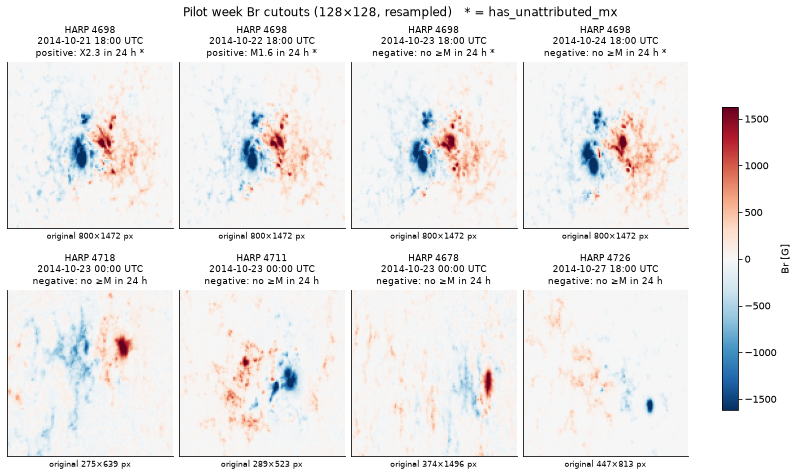

In [20]:
if cutouts is None or obs is None:
    skip("pilot cutouts or observations")
else:
    pilot = cut_index.astype({"HARPNUM": "int64"}).merge(
        obs.astype({"HARPNUM": "int64"}), on=["HARPNUM", "T_REC"], how="left", validate="one_to_one"
    )
    aspect = pilot.orig_nx / pilot.orig_ny
    print(f"cutouts: {len(pilot)} from {pilot.HARPNUM.nunique()} HARPs, without a matching observation: "
          f"{pilot.label.isna().sum()}; with NaN pixels before resampling: {(pilot.nan_fraction > 0).sum()} "
          f"(max {pilot.nan_fraction.max():.1%}); original aspect ratio (width/height) {aspect.min():.1f} to "
          f"{aspect.max():.1f}")
    pilot = pilot[pilot.label.notna()]
    # HARP 4698 at 18 UTC on the four days up to the X flare (2014-10-24 21:41), then one row of four other HARPs
    days = pd.to_datetime(["2014-10-21 18:00", "2014-10-22 18:00", "2014-10-23 18:00", "2014-10-24 18:00"], utc=True)
    big = pilot[pilot.HARPNUM == 4698].set_index("slot_time").sort_index()
    big = big.iloc[np.unique(big.index.get_indexer(days, method="nearest"))].reset_index()
    rest = pilot[pilot.HARPNUM != 4698].sort_values(["label", "has_unattributed_mx", "slot_time"])  # clean negatives first
    others = rest.groupby("HARPNUM").head(1).assign(n=lambda d: d.HARPNUM.map(rest.HARPNUM.value_counts()))
    others = others.nlargest(8 - len(big), "n").sort_values("slot_time")
    pick = pd.concat([big, others], ignore_index=True)

    imgs = cutouts[pick["index"].to_numpy()].astype("float32")
    vmax = float(np.nanpercentile(np.abs(imgs), 99.5))  # one symmetric scale for all panels
    fig, axes = plt.subplots(2, 4, figsize=(11, 6.6), dpi=72, constrained_layout=True)  # ~1 screen px per cutout px
    for ax, img, r in zip(axes.flat, imgs, pick.itertuples()):
        im = ax.imshow(img, cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="lower")
        label = f"positive: {r.label_class} in 24 h" if r.label == 1 else "negative: no ≥M in 24 h"
        flag = " *" if r.has_unattributed_mx else ""
        ax.set_title(f"HARP {r.HARPNUM}\n{r.slot_time:%Y-%m-%d %H:%M} UTC\n{label}{flag}", fontsize=9)
        ax.set_xlabel(f"original {r.orig_ny}×{r.orig_nx} px", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in axes.flat[len(pick):]:
        ax.axis("off")
    fig.colorbar(im, ax=axes, shrink=0.7, label="Br [G]")
    fig.suptitle("Pilot week Br cutouts (128×128, resampled)   * = has_unattributed_mx")
    plt.show()

## 6. First look

### 6.1 Missing values

Flares: many gaps are structural. Science-only flares have no `ops_*` columns, and operational-only flares have no
`sci_*` columns. The gap that matters is the NOAA region number: without it a flare cannot be tied to a HARP.

In [21]:
mx = flares.peak_flux >= 1e-5
print(f"flares with no NOAA region: {flares.noaa_ar.isna().sum():,} of {len(flares):,} ({flares.noaa_ar.isna().mean():.0%})")
print(f"M/X flares (science scale) with no NOAA region: {flares[mx].noaa_ar.isna().sum():,} of {mx.sum():,} "
      f"({flares[mx].noaa_ar.isna().mean():.0%})")
flares.isna().sum().loc[lambda s: s > 0].to_frame("missing").T

flares with no NOAA region: 14,060 of 20,482 (69%)
M/X flares (science scale) with no NOAA region: 434 of 1,260 (34%)


,peak_time,noaa_ar,location,match_dt_s,sci_flare_id,sci_start,sci_peak,sci_end,sci_class,sci_peak_flux,sci_background_flux,sci_integrated_flux,sci_seq_num,sci_file,ops_start,ops_peak,ops_end,ops_class,ops_flux,ops_location,ops_noaa_ar,ops_satellite,ops_integrated_flux,ops_flag,ops_source,ops_file,ops_line
missing,1,14060,15881,9044,1311,1311,1311,3686,1311,1311,1311,1311,1311,1311,7733,7734,7733,7733,7733,15881,14060,7733,7734,20482,7733,7733,7733


Raw keywords: JSOC writes the string `"MISSING"` instead of a null. HARPs that have no NOAA region (`NOAA_AR = 0`)
are usually small, short-lived patches, and most of the gaps are there. Those rows are removed by the
NOAA-numbered rule anyway.

In [22]:
if kw_raw is None:
    skip(KW_PILOT)
else:
    has_noaa = kw.NOAA_AR > 0
    miss = pd.DataFrame({
        "MISSING, NOAA_AR = 0": (kw_raw[~has_noaa] == "MISSING").sum(),
        "MISSING, NOAA_AR > 0": (kw_raw[has_noaa] == "MISSING").sum(),
        "zero, NOAA_AR > 0": (kw[has_noaa][SHARP_PARAMS] == 0).sum(),
    }).fillna(0).astype(int)
    print(f"pilot records: {len(kw):,}, of which NOAA_AR = 0: {(~has_noaa).sum():,} ({(~has_noaa).mean():.0%})")
    display(miss.loc[miss.any(axis=1)].T)

pilot records: 12,960, of which NOAA_AR = 0: 7,158 (55%)


,ABSNJZH,AREA_ACR,LAT_FWT,LAT_MAX,LAT_MIN,LON_FWT,LON_MAX,LON_MIN,MEANALP,MEANGAM,MEANGBH,MEANGBT,MEANGBZ,MEANJZD,MEANJZH,MEANPOT,MEANSHR,NOAA_ARS,R_VALUE,SAVNCPP,SHRGT45,TOTPOT,TOTUSJH,TOTUSJZ,USFLUX
"MISSING, NOAA_AR = 0",0,1811,1816,1811,1811,1816,1811,1811,1813,1813,1813,1813,1813,1813,1813,1813,1813,7158,0,0,1813,0,0,0,0
"MISSING, NOAA_AR > 0",0,488,488,488,488,488,488,488,521,522,521,521,521,521,521,521,524,0,0,0,521,0,0,0,0
"zero, NOAA_AR > 0",521,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,699,521,28,521,521,521,521


Observations: missing values per column after the filters.

In [23]:
if obs is None:
    skip(OBS)
else:
    n_missing = obs.isna().sum()
    print(f"columns with gaps: {(n_missing > 0).sum()} of {obs.shape[1]}")
    display(n_missing[n_missing > 0].to_frame("missing").T)

columns with gaps: 16 of 48


,label_class,label_flux,label_peak_time,label_attribution_method,label_ops_class,label_ops_flux,MEANGAM,MEANGBT,MEANGBZ,MEANGBH,MEANJZD,MEANALP,MEANJZH,MEANPOT,MEANSHR,SHRGT45
missing,28856,28856,28856,28856,28856,28856,5,5,5,5,5,5,5,5,53,5


### 6.2 Duplicates

Exact duplicate rows, and duplicates on the key that should be unique: peak time and class for flares,
`(HARPNUM, T_REC)` for keywords and observations. The flares that share a key, or have no peak time at all, are
listed below the counts.

In [24]:
dups = {
    "flares, exact rows": flares.duplicated().sum(),
    "flares, same peak time + class": flares.duplicated(["peak_time", "goes_class"]).sum(),
}
if kw_raw is not None:
    dups["keywords, (HARPNUM, T_REC)"] = kw_raw.duplicated(["HARPNUM", "T_REC"]).sum()
if obs is not None:
    dups["observations, (HARPNUM, T_REC)"] = obs.duplicated(["HARPNUM", "T_REC"]).sum()
display(pd.Series(dups, name="duplicates").to_frame())

odd = flares[flares.duplicated(["peak_time", "goes_class"], keep=False) | flares.peak_time.isna()]
print("flares sharing peak time and class, or without a peak time:")
odd[["peak_time", "goes_class", "match", "ops_start", "ops_end", "ops_file", "ops_line"]]

,duplicates
"flares, exact rows",0
"flares, same peak time + class",3
"keywords, (HARPNUM, T_REC)",0
"observations, (HARPNUM, T_REC)",0


flares sharing peak time and class, or without a peak time:


,peak_time,goes_class,match,ops_start,ops_end,ops_file,ops_line
729,2011-03-05 09:08:00+00:00,C3.1,matched,2011-03-05 05:41:00+00:00,2011-03-05 09:18:00+00:00,goes-xrs-report_2011.txt,427
730,2011-03-05 09:08:00+00:00,C3.1,ops_only,2011-03-05 09:01:00+00:00,2011-03-05 09:15:00+00:00,goes-xrs-report_2011.txt,428
5990,2012-09-15 21:47:00+00:00,C1.2,matched,2012-09-15 21:42:00+00:00,2012-09-15 21:50:00+00:00,goes-xrs-report_2012.txt,1509
5991,2012-09-15 21:47:00+00:00,C1.2,ops_only,2012-09-15 21:42:00+00:00,2012-09-15 21:50:00+00:00,goes-xrs-report_2012.txt,1508
9189,2013-10-21 20:34:00+00:00,C2.2,matched,2013-10-21 20:20:00+00:00,2013-10-21 20:39:00+00:00,goes-xrs-report_2013.txt,1482
9190,2013-10-21 20:34:00+00:00,C2.2,ops_only,2013-10-21 20:29:00+00:00,2013-10-21 20:46:00+00:00,goes-xrs-report_2013.txt,1483
20481,NaT,C3.5,ops_only,2011-04-11 23:40:00+00:00,2011-04-12 00:03:00+00:00,goes-xrs-report_2011.txt,659


### 6.3 Class balance per split, on both flux scales

The label uses the **science-quality** scale. The operational list that forecasters know uses the older scale, which
is 0.7× smaller. A flare that is M1.0 on the operational scale is ≈M1.4 on the science scale, so the same "≥M1.0"
rule gives more positives on the science scale. Both are shown so the base rates can be compared with published
work that uses the operational list.

Flare counts per split (by peak date):

In [25]:
OPS_SCALE = 0.7  # operational flux = science flux x 0.7

flares["split"] = flares.peak_time.dt.year.map(split_of_year)
flare_balance = flares.groupby("split").agg(
    flares=("peak_flux", "size"),
    MX_science=("peak_flux", lambda f: (f >= 1e-5).sum()),
    MX_operational=("peak_flux", lambda f: (f * OPS_SCALE >= 1e-5).sum()),
    X_science=("peak_flux", lambda f: (f >= 1e-4).sum()),
).reindex(list(SPLITS))
flare_balance

,flares,MX_science,MX_operational,X_science
split,,,,
train,13520,972,612,64
val,3045,199,131,6
replay,3916,89,62,7


Observation-level class balance per split. Positive means the largest attributed flare in the next 24 h is ≥M1.0 on
that scale. Negatives flagged `has_unattributed_mx` stay in the file with label 0. An M/X flare that could not be tied
to any region peaked somewhere on the disk in their window, so some of them may really be positives. Excluding them
is a training-time choice. The last column shows the positive rate if they are excluded.

In [26]:
if obs is None:
    skip(OBS)
else:
    is_neg = obs.label == 0
    by_split = obs.assign(neg=is_neg, flagged_neg=is_neg & obs.has_unattributed_mx).groupby("split")
    balance = pd.DataFrame({
        "observations": by_split.size(),
        "positives (science)": by_split.label.sum(),
        "positives (operational)": by_split.label_ops.sum(),
        "negatives": by_split.neg.sum(),
        "flagged negatives": by_split.flagged_neg.sum(),
    }).reindex(list(SPLITS)).fillna(0).astype(int)
    balance["rate (science)"] = balance["positives (science)"] / balance["observations"]
    balance["rate (operational)"] = balance["positives (operational)"] / balance["observations"]
    balance["share of negatives flagged"] = balance["flagged negatives"] / balance["negatives"]
    balance["rate (science), flagged negatives excluded"] = balance["positives (science)"] / (
        balance["observations"] - balance["flagged negatives"]
    )
    display(balance.round(3))

,observations,positives (science),positives (operational),negatives,flagged negatives,rate (science),rate (operational),share of negatives flagged,"rate (science), flagged negatives excluded"
split,,,,,,,,,
train,25051,1086,769,23965,2896,0.043,0.031,0.121,0.049
val,5837,233,164,5604,659,0.040,0.028,0.118,0.045
replay,5477,77,53,5400,100,0.014,0.010,0.019,0.014


### 6.4 SHARP parameter ranges

Summary statistics of the 18 tabular features. Several of them are extensive quantities that grow with region size
(`USFLUX`, `TOTUSJZ`, `TOTPOT`, `AREA_ACR`) and span many orders of magnitude, so they will need a log transform.
Zeros in quantities that must be positive point to bad records rather than physics.

In [27]:
if obs is None and kw is None:
    skip(OBS)
else:
    params = obs[SHARP_PARAMS] if obs is not None else kw.loc[kw.NOAA_AR > 0, SHARP_PARAMS]
    ranges = params.describe(percentiles=[0.01, 0.5, 0.99]).T
    ranges["zeros"] = (params == 0).sum()
    ranges["negative"] = (params < 0).sum()
    print("source:", "observations" if obs is not None else "pilot keywords with a NOAA region")
    with pd.option_context("display.float_format", "{:.3g}".format):
        display(ranges)

source: observations


,count,mean,std,min,1%,50%,99%,max,zeros,negative
USFLUX,3.64e+04,1.09e+22,1.42e+22,0,1.23e+20,5.9e+21,6.5e+22,2.06e+23,5,0
MEANGAM,3.64e+04,38,9.73,16.7,22.3,36.3,60.6,80,0,0
MEANGBT,3.64e+04,114,21.6,46.7,72.3,112,169,288,0,0
MEANGBZ,3.64e+04,115,21.1,47.2,74.6,113,170,255,0,0
MEANGBH,3.64e+04,54.5,14.4,19.9,26.8,54.1,92.3,169,0,0
MEANJZD,3.64e+04,0.198,0.495,-8.56,-0.812,0.121,1.79,11,0,12351
TOTUSJZ,3.64e+04,1.53e+13,1.99e+13,0,2.27e+11,8.29e+12,9.11e+13,2.4e+14,5,0
MEANALP,3.64e+04,-0.00118,0.0222,-0.388,-0.0627,-0.000686,0.0585,0.668,0,18807
MEANJZH,3.64e+04,-0.000406,0.00754,-0.0921,-0.022,-0.000227,0.0205,0.0672,0,18808
TOTUSJH,3.64e+04,745,1.04e+03,0,9.87,389,4.8e+03,1.43e+04,5,0


### 6.5 Longitude: |LON_FWT|

Near the limb the line-of-sight field is foreshortened and the SHARP parameters become unreliable. The rule keeps
|LON_FWT| ≤ 60°. The raw pilot records show how much of each HARP's disk passage is cut off. The observations
must not contain anything beyond 60°.

pilot records with a NOAA region beyond 60°: 24.3%
observations beyond 60°: 0, missing LON_FWT: 0


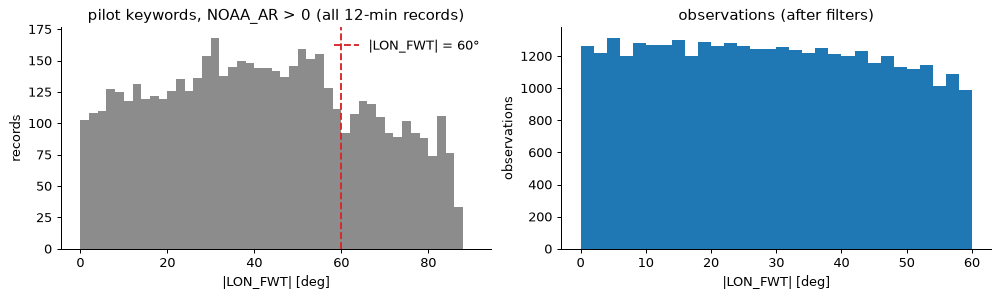

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), constrained_layout=True)
if kw is not None:
    lon = kw.loc[kw.NOAA_AR > 0, "LON_FWT"].abs().dropna()
    axes[0].hist(lon, bins=np.arange(0, 92, 2), color="0.55")
    axes[0].axvline(60, color="C3", ls="--", label="|LON_FWT| = 60°")
    axes[0].set(title="pilot keywords, NOAA_AR > 0 (all 12-min records)", xlabel="|LON_FWT| [deg]", ylabel="records")
    axes[0].legend(frameon=False)
    print(f"pilot records with a NOAA region beyond 60°: {(lon > 60).mean():.1%}")
if obs is not None:
    lon_obs = pd.to_numeric(obs.LON_FWT, errors="coerce").abs()
    axes[1].hist(lon_obs, bins=np.arange(0, 62, 2), color="C0")
    axes[1].set(title="observations (after filters)", xlabel="|LON_FWT| [deg]", ylabel="observations")
    print(f"observations beyond 60°: {(lon_obs > 60).sum()}, missing LON_FWT: {lon_obs.isna().sum()}")
plt.show()

### 6.6 Missing 6-hour slots

JSOC records are sometimes missing exactly at 00/06/12/18, which is why the pipeline takes the nearest record within
±60 min instead of the record at the slot time. The pilot keywords show how often each rule finds a record. "Exact"
allows ±1 min, because the TAI–UTC offset is 35 s in 2014.

In [29]:
if kw is None:
    skip(KW_PILOT)
else:
    rec = kw.loc[kw.NOAA_AR > 0, ["HARPNUM", "t_rec_utc"]].sort_values("t_rec_utc")
    slots = pd.concat(
        pd.DataFrame({"HARPNUM": h, "slot": pd.date_range(t.min().ceil("6h"), t.max().floor("6h"), freq="6h")})
        for h, t in rec.groupby("HARPNUM").t_rec_utc
    ).sort_values("slot")
    near = pd.merge_asof(slots, rec, left_on="slot", right_on="t_rec_utc", by="HARPNUM", direction="nearest")
    dt_s = (near.t_rec_utc - near.slot).dt.total_seconds().abs()
    print(f"pilot slots inside the life of a NOAA-numbered HARP: {len(near)}")
    print(f"  a record at the exact slot time (±1 min): {(dt_s <= 60).mean():.1%}")
    print(f"  a record within ±60 min (pipeline rule):  {(dt_s <= 3600).mean():.1%}")

pilot slots inside the life of a NOAA-numbered HARP: 200
  a record at the exact slot time (±1 min): 68.0%
  a record within ±60 min (pipeline rule):  100.0%


Over the full period, from the step 3 build stats. Gaps in `observations.parquet` mix missing records with slots
removed by the filters, so they are not counted from the file. "Lifetime" counts every slot between a NOAA-numbered
HARP's first and last record. "Kept span" counts only the part that passes the filters. The second print shows how far
the chosen record is from its nominal slot time; preferring `QUALITY = 0` records moves some slots away from the
nearest record.

In [30]:
if obs is None:
    skip(OBS)
else:
    for name, m in build_obs["missing_slots"].items():
        print(f"{name}: {m['missing']:,} of {m['expected']:,} slots have no record within ±60 min "
              f"({m['missing'] / max(m['expected'], 1):.2%}); by split {m['missing_by_calendar_split']}")
    offset_min = obs.slot_offset_s.abs() / 60
    print(f"|record time - slot time|: median {offset_min.median():.1f} min, 95th percentile "
          f"{offset_min.quantile(0.95):.1f} min, over 30 min: {(offset_min > 30).mean():.1%} of observations")

harp_lifetime: 1,287 of 102,644 slots have no record within ±60 min (1.25%); by split {'replay': 402, 'train': 776, 'val': 109}
kept_span: 383 of 37,041 slots have no record within ±60 min (1.03%); by split {'replay': 89, 'train': 259, 'val': 35}
|record time - slot time|: median 0.6 min, 95th percentile 12.6 min, over 30 min: 0.7% of observations


### 6.7 Flare attribution

A flare only counts toward a HARP's label if it can be tied to a NOAA region in that HARP. The methods, in order: the
region number from the operational list; inheritance by a sub-peak inside an operational flare's start–end window;
location inside the HARP bounding box or near its flux-weighted centre; otherwise unattributed.

In [31]:
FLARES_ATT = "interim/flares_attributed.parquet"
if exists(FLARES_ATT):
    fa = read_parquet(FLARES_ATT)
    fa_mx = fa[fa.peak_flux >= 1e-5].dropna(subset=["peak_time"])
    att = pd.crosstab(fa_mx.peak_time.dt.year.rename("year"), fa_mx.attribution_method)
    att["unattributed share"] = (att.get("unattributed", 0) / att.sum(axis=1)).round(3)
    att.insert(0, "split", att.index.map(split_of_year))
    print("M/X flares (science scale) by attribution method:")
    display(att)
    print("all flares by method:", fa.attribution_method.value_counts().to_dict())
else:
    skip(FLARES_ATT)
    print("Region numbers from the operational list only (method a):")
    display(flares[flares.peak_flux >= 1e-5].groupby("split", sort=False).noaa_ar.agg(
        MX="size", with_region="count").assign(without_region=lambda d: d.MX - d.with_region))

M/X flares (science scale) by attribution method:


attribution_method,split,location_bbox,ops_region,subpeak,unattributed,unattributed share
year,,,,,,
2011,train,0,178,13,15,0.073
2012,train,2,127,3,73,0.356
2013,train,3,112,1,57,0.329
2014,train,7,220,21,140,0.361
2015,val,5,121,6,67,0.337
2016,replay,2,17,0,8,0.296
2017,replay,0,51,6,5,0.081


all flares by method: {'unattributed': 13150, 'ops_region': 6422, 'subpeak': 720, 'location_bbox': 184, 'location_fwt': 6}


### 6.8 `has_unattributed_mx`, multi-NOAA HARPs and QUALITY flags

- `has_unattributed_mx`: an ≥M flare peaked somewhere on the disk in the next 24 h, but could not be tied to any
  region. On a negative this means the label may be wrong. The rows are kept and flagged; excluding them is decided
  at training time.
- multi-NOAA: one HARP contains several NOAA regions (`NOAA_NUM > 1`). It is labelled with the largest flare of any
  of them.
- `QUALITY != 0`: HMI flagged something about the record. Step 3 already prefers an unflagged record within ±60 min,
  so a flag remains only when no unflagged record existed near the slot. These rows are kept and flagged for now.

In [32]:
if obs is None:
    skip(OBS)
else:
    flags = obs.groupby("split").agg(
        observations=("HARPNUM", "size"),
        has_unattributed_mx=("has_unattributed_mx", "sum"),
        multi_noaa=("multi_noaa", "sum"),
        quality_nonzero=("quality_nonzero", "sum"),
    ).reindex(list(SPLITS)).fillna(0).astype(int)
    display(flags)
    print("multi-NOAA HARPs:", obs.loc[obs.multi_noaa, "HARPNUM"].nunique())
    print("most common QUALITY values:")
    display(obs.QUALITY.map("0x{:08X}".format).value_counts().head(8).to_frame("observations").T)

,observations,has_unattributed_mx,multi_noaa,quality_nonzero
split,,,,
train,25051,3199,6829,162
val,5837,727,1215,3
replay,5477,117,639,2869


multi-NOAA HARPs: 237
most common QUALITY values:


QUALITY,0x00000000,0x00000080,0x00010080,0x00010420,0x00000020,0x00010400,0x00001080,0x00000400
observations,33331,1421,1392,62,58,19,18,16


QUALITY is a bit mask. The names come from JSOC's list of HMI quality bits
([QUALITY.txt](http://jsoc.stanford.edu/doc/data/hmi/Quality_Bits/QUALITY.txt)). These bits mark data products that
were created under sub-optimal conditions:

- `0x20` POORQUALITY: eclipse, lunar transit, thermal recovery, open ISS or other issues
- `0x80` TEMPERROR: "code error discovered, will be corrected in later versions"
- `0x400` NOCOSMICRAY: some cosmic-ray hit lists could not be read
- `0x1000` NOGAPFILL: the filtergrams could not all be gap-filled
- `0x10000` LOWINTERPNUM: fewer averaging/interpolation points than nominal

Step 3 prefers unflagged records, so a flag is left only where no unflagged record existed within ±60 min. The tables
show the share of observations with each bit set, by slot hour and by year.

In [33]:
if obs is None:
    skip(OBS)
else:
    QUALITY_BITS = {0x20: "POORQUALITY", 0x80: "TEMPERROR", 0x400: "NOCOSMICRAY", 0x1000: "NOGAPFILL",
                    0x10000: "LOWINTERPNUM"}
    bits = pd.DataFrame({f"0x{b:X} {name}": (obs.QUALITY & b) > 0 for b, name in QUALITY_BITS.items()})
    bits["any bit (QUALITY != 0)"] = obs.quality_nonzero
    display(bits.groupby(obs.slot_time.dt.hour.rename("slot hour (UTC)")).mean().round(2))
    display(bits.groupby(obs.slot_time.dt.year.rename("year")).mean().round(2))

,0x20 POORQUALITY,0x80 TEMPERROR,0x400 NOCOSMICRAY,0x1000 NOGAPFILL,0x10000 LOWINTERPNUM,any bit (QUALITY != 0)
slot hour (UTC),,,,,,
0,0.0,0.08,0.00,0.0,0.00,0.08
6,0.0,0.08,0.01,0.0,0.08,0.08
12,0.0,0.08,0.00,0.0,0.00,0.08
18,0.0,0.08,0.01,0.0,0.08,0.08


,0x20 POORQUALITY,0x80 TEMPERROR,0x400 NOCOSMICRAY,0x1000 NOGAPFILL,0x10000 LOWINTERPNUM,any bit (QUALITY != 0)
year,,,,,,
2011,0.00,0.00,0.00,0.00,0.00,0.00
2012,0.00,0.00,0.00,0.00,0.00,0.00
2013,0.02,0.00,0.01,0.00,0.01,0.02
2014,0.00,0.00,0.00,0.00,0.00,0.00
2015,0.00,0.00,0.00,0.00,0.00,0.00
2016,0.00,0.64,0.00,0.01,0.31,0.64
2017,0.00,0.30,0.01,0.01,0.15,0.30


### 6.9 Coverage over time

Solar cycle 24 peaked in 2014. By 2016–2017 the Sun is much quieter: fewer regions, fewer records and far fewer
M/X flares. This matters for the held-out replay split.

,MX flares (science),X flares (science),keyword records,observations,HARPs,positives
year,,,,,,
2011,206,12,426964,5921,197,252
2012,205,12,477179,5743,199,200
2013,173,13,551906,7044,244,261
2014,388,27,600952,6218,195,361
2015,199,6,521477,5958,197,245
2016,27,1,271858,3636,133,33
2017,62,6,121579,1845,63,44


2016: 27 M/X flares; top regions {'no region': 10, 12567: 5, 12497: 4}; busiest month 7 (10)
2017: 62 M/X flares; top regions {12673: 35, 'no region': 11, 12644: 5}; busiest month 9 (42)


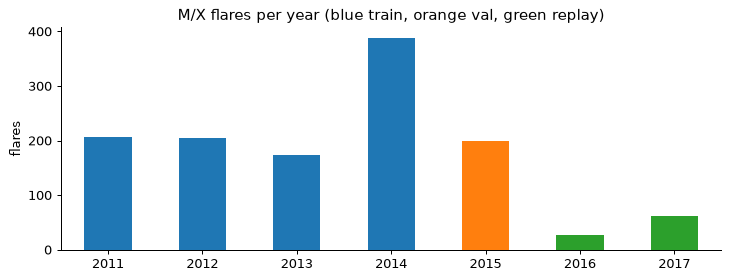

In [34]:
dated = flares.dropna(subset=["peak_time"])
yearly = pd.DataFrame({
    "MX flares (science)": dated[dated.peak_flux >= 1e-5].groupby(dated.peak_time.dt.year).size(),
    "X flares (science)": dated[dated.peak_flux >= 1e-4].groupby(dated.peak_time.dt.year).size(),
}).rename_axis("year")
if len(kw_month_rows):
    yearly["keyword records"] = kw_month_rows.groupby(kw_month_rows.index.str[:4].astype(int)).sum()
if obs is not None:
    obs_year = obs.slot_time.dt.year
    yearly["observations"] = obs.groupby(obs_year).size()
    yearly["HARPs"] = obs.groupby(obs_year).HARPNUM.nunique()
    yearly["positives"] = obs.groupby(obs_year).label.sum()
yearly = yearly.fillna(0).astype(int)
display(yearly)

fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
replay_mx = dated[(dated.peak_flux >= 1e-5) & (dated.peak_time.dt.year >= 2016)]
for year, g in replay_mx.groupby(replay_mx.peak_time.dt.year):
    top = {("no region" if pd.isna(k) else int(k)): int(n) for k, n in g.noaa_ar.value_counts(dropna=False).head(3).items()}
    print(f"{year}: {len(g)} M/X flares; top regions {top}; "
          f"busiest month {g.peak_time.dt.month.value_counts().idxmax()} ({g.peak_time.dt.month.value_counts().max()})")

split_colors = {"train": "C0", "val": "C1", "replay": "C2"}
yearly["MX flares (science)"].plot.bar(ax=ax, color=[split_colors[split_of_year(y)] for y in yearly.index], rot=0)
ax.set(title="M/X flares per year (blue train, orange val, green replay)", xlabel="", ylabel="flares")
plt.show()

## 7. Findings

**Size.**
- Flares: 20,482 flares from 2011 to 2017 (31 columns, 2.3 MB).
- Raw SHARP keywords: 2,971,915 twelve-minute records in 84 monthly files (32 columns, 478 MB).
- Observations: 36,365 HARP × 6-hour slots from 1,206 HARPs (48 columns, 7.8 MB).
- Features: 18 SHARP summary parameters per observation for the tabular models, plus one 128×128 Br image for the CNN.
- Images: so far only the pilot week, 139 cutouts from 9 HARPs (4.6 MB).

**What checks out.**
- No duplicate `(HARPNUM, T_REC)` in the keywords or the observations.
- Every monthly keyword file has the row count recorded in the retrieval log.
- The known-value checks from the plan pass.
- The ±60 min sampling rule is needed and works. In the pilot week only 68% of slots have a record at the exact clock
  time, but all of them have one within ±60 min. Over the full period, 1,287 of 102,644 slots in HARP lifetimes
  (1.3%) have no record within ±60 min. Because unflagged records are preferred, the chosen record is up to
  12.6 min from its slot for 95% of observations, and more than 30 min away for 0.7%.

**Class balance (science scale, ≥M1.0 in 24 h).**

| split  | positives | positive rate | negatives per positive | operational-scale rate |
| ------ | --------: | ------------: | ---------------------: | ---------------------: |
| train  |     1,086 |          4.3% |                     22 |                   3.1% |
| val    |       233 |          4.0% |                     24 |                   2.8% |
| replay |        77 |          1.4% |                     70 |                   1.0% |

### Problems without a fix yet (for report section 6.4)

1. **Flares that cannot be tied to a region.** 365 of 1,260 M/X flares (29%) stay unattributed after all three
   methods. In 2012–2015 the share is 33–36%. Location matching recovers only 19 M/X flares, because most flares
   without a region number also have no location in the operational list. As a result, 3,655 of 34,969 negatives
   (10.5%) carry `has_unattributed_mx`: 12% in train and val, but only 2% in replay. In the pilot week (AR 12192) it is
   92% of negatives. These rows are kept with label 0. Excluding them would raise the train positive rate from 4.3% to
   4.9%. That decision is left to training time. Because the flag is much rarer in replay, train and replay negatives
   are not equally clean.
2. **The replay split is small, quiet and dominated by one region.**
   - 2016–2017 have 89 M/X flares, against 972 in 2011–2014. That gives 77 positive observations (33 in 2016, 44 in
     2017) and a base rate of 1.4%, against 4.0% in the validation year.
   - 35 of the 62 M/X flares of 2017 come from one region (AR 12673), and 42 of them fall in September 2017.
   - Coverage also drops: 2017 has 1,845 observations from 63 HARPs, against 6,218 from 195 HARPs in 2014.
   - What this means for replay: a few positives decide recall and TSS, so confidence intervals will be wide and
     should be bootstrapped by HARP. A threshold chosen on 2015 will give lower precision at the lower base rate, so
     base-rate-insensitive scores (TSS) and calibration should be reported next to precision. Replay is close to a
     test on one active-region episode.
3. **QUALITY flags are rare in train and val but cover half of replay.**
   - The nearest record carried a flag for 54,164 of 102,700 HARP slots, mostly bits 0x400 and 0x10000 at 06 and
     18 UTC. Step 3 therefore prefers an unflagged record within ±60 min: 47,284 slots switched to one, and 6,880 had
     none.
   - `QUALITY != 0` remains on 0.6% of train, 0.05% of val, but 52.4% of replay.
   - Almost all of it is bit 0x80 (TEMPERROR), which JSOC describes as a "code error discovered, will be corrected in
     later versions". It is set on 64% of 2016 and 30% of 2017 observations.
   - Unresolved: dropping 0x80 rows would remove half of replay, while keeping them means replay is built largely from
     records JSOC flags for a code error. Whether corrected data exist has not been checked.
4. **The filters remove most candidate slots.** Of 102,700 HARP slots with a record, 36,365 are kept.
   `NOAA_AR = 0` removes 51,095, |LON_FWT| > 60° removes 10,327, and a missing LON_FWT removes 4,913. The model never
   sees un-numbered regions, and flares from them are part of the unattributed problem in item 1.
5. **Bad and awkward feature values.**
   - Five observations with almost no active pixels (`AREA_ACR` < 1, `USFLUX = 0` or missing means) pass the filters.
   - `MEANSHR` is missing in 53 rows.
   - `R_VALUE` is exactly 0 in 10,261 rows (28%), a physical floor that will show up as a spike.
   - The extensive parameters (`USFLUX`, `TOTUSJZ`, `TOTPOT`, `SAVNCPP`) span three to four orders of magnitude and
     need a log transform.
6. **Multi-region HARPs.** 237 HARPs (8,683 observations, 24%) contain more than one NOAA region. Their label is the
   largest flare of any of those regions, while the features describe the whole patch.
7. **Flare table oddities.**
   - One operational-only flare (C3.5, 2011-04-11 23:40 to 00:03 UTC) has no peak time.
   - Three pairs of C-class flares share the same peak time and class. Each pair is two consecutive lines of the
     operational report: one line is matched to a science flare, the other is kept as an operational-only flare. The
     2012 pair is an exact duplicate line (same start and end); the 2011 and 2013 pairs start at different times.
     The pairs are C-class, so the labels are not affected, but the flare counts include three possible double
     counts.
   - Region numbers for the second half of 2017 come from SWPC daily reports, a different source.
8. **Split boundaries.** 9 HARPs cross a split boundary (7 train/val, 2 val/replay). They are kept whole in the earlier
   split, which moves 129 observations from early 2015/2016 into the previous split.
9. **Cutouts.** Only the pilot week exists so far; the full download is step 6. The plain resize to 128×128 stretches
   non-square cutouts: aspect ratios in the pilot go from 1.3 to 4.0 (HARP 4678, 374×1496 px). A CNN would see shapes
   distorted by different amounts. Two pilot cutouts had NaN pixels (at most 4.1%), which were set to 0 before
   resampling.